In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34745,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44555,Total threads: 8
Dashboard: http://127.0.0.1:44543/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:39557,


2026-03-31 15:55:28,814 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f86b4283380>, <Task finished name='Task-278220' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.on

In [2]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

prefix = ['diag_state']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
lon_str = '140'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_140 = xr.open_dataset(TAO_ADCP_file)

lon_str = '110'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_110 = xr.open_dataset(TAO_ADCP_file)

lon_str = '170'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_170 = xr.open_dataset(TAO_ADCP_file)

dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

/tmp/ipykernel_143231/1577621949.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_143231/1577621949.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_143231/1577621949.py:13: FutureWarning: In a future version of xarray t

In [5]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()

# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

In [6]:
def correlation_tao(U, U_TAO):
    # compute the correlation v depth between the two data sets which are time v depth
    corr = xr.corr(U, U_TAO, dim='time')
    return corr

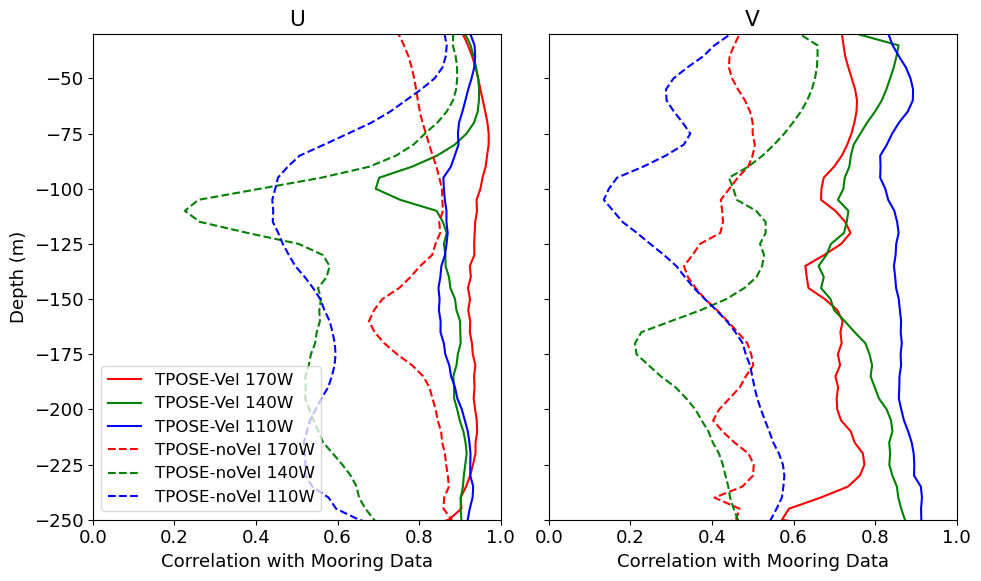

In [18]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    nrows=1,
    ncols=2,
    sharey=True
)

XGs = [190, 220, 250]
colors = ['r', 'g', 'b']

for xg, color in zip(XGs,colors):
    # ------------------
    # Correlation in U
    # ------------------
    U_withTAO = tpose_U_TAO.sel(XG=xg)
    corr = correlation_tao(U_withTAO, dsTAO.u_1205.sel(XC=xg))
    corr.plot(ax=ax[0], y='Z', color=color, label='TPOSE-Vel '+str(abs(xg-360))+'W')

    # ------------------
    # Correlation in V
    # ------------------
    V_withTAO = tpose_V_TAO.sel(XC=xg)
    corr = correlation_tao(V_withTAO, dsTAO.v_1206.sel(XC=xg))
    corr.plot(ax=ax[1], y='Z', color=color, label='TPOSE-Vel '+str(abs(xg-360))+'W')

for xg, color in zip(XGs,colors):
    U_noTAO = tpose_U_noTAO.sel(XG=xg)
    corr_noTAO = correlation_tao(U_noTAO, dsTAO.u_1205.sel(XC=xg))
    corr_noTAO.plot(ax=ax[0], y='Z', color=color, ls='--', label='TPOSE-noVel '+str(abs(xg-360))+'W')

    V_noTAO = tpose_V_noTAO.sel(XC=xg)
    corr_noTAO = correlation_tao(V_noTAO, dsTAO.v_1206.sel(XC=xg))
    corr_noTAO.plot(ax=ax[1], y='Z', color=color, ls='--', label='TPOSE-noVel '+str(abs(xg-360))+'W')

ax[0].axvline(0, color='k', lw=0.5,label='_nolabel_')
ax[1].axvline(0, color='k', lw=0.5, label='_nolabel_')
ax[0].set_title('U')
ax[0].set_ylim(-250, -30)
ax[0].set_xlim(0.0, 1.0)
ax[0].set_xlabel('Correlation with Mooring Data')
ax[1].set_title('V')
ax[1].set_ylim(-250, -30)
ax[1].set_xlim(0.0, 1.0)
ax[1].set_xlabel('Correlation with Mooring Data')
ax[1].set_ylabel('')
ax[0].set_ylabel('Depth (m)')

ax[0].legend(loc='lower left', framealpha=0.75, fontsize=12)
plt.tight_layout()
fig.savefig(foldername + 'correlation.png')

In [20]:
client.shutdown()
client.close()
cluster.close()